# One-Phonon Diffuse Scattering — Rigid-Body Crystal (6o2h, P1)

One rigid body per unit cell (whole lysozyme molecule), 6 DOF: $(\Omega, v)$.

**Pipeline:** hybrid density → interface detection → K-matrix input →
dynamical matrix → diffuse map → band structure → in-notebook surface animation.


In [1]:
import numpy as np
import gemmi
import pathlib
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.linalg import eigh
from itertools import product

np.set_printoptions(precision=4, suppress=True)


In [2]:
PDB_FILE = pathlib.Path("6o2h.cif")
SF_CIF   = pathlib.Path("6o2h-sf.cif")

D_MIN_MODEL    = 1.5    # Å — resolution for model density (phases)
RATE_MODEL     = 1.5
CONTACT_CUTOFF = 4.0    # Å — atom-atom cutoff for interface detection
MIN_CONTACTS   = 5
MAX_IMAGE      = 1      # check ±MAX_IMAGE cells each direction
KAPPA_T        = 1.0    # default translational stiffness (k_BT/Å²)
KAPPA_R        = 1.0    # default rotational stiffness (k_BT)
D_MIN_DIFFUSE  = 3.0    # Å — resolution cutoff for diffuse map
NPLOT_HK       = 8      # sub-integer grid density per Miller index (finer = slower)
                        # Trade-off: D_MIN_DIFFUSE controls how many Bragg peaks appear
                        # (larger D_MIN → fewer peaks, only large-d ones); NPLOT_HK controls
                        # inter-Bragg resolution independently. To trade fewer Bragg peaks for
                        # finer sub-Bragg sampling at fixed memory: increase D_MIN_DIFFUSE and
                        # NPLOT_HK proportionally (h_max ∝ 1/D_MIN, map pixels ∝ h_max*P).
TEMPERATURE    = 300.0  # K


In [3]:
st = gemmi.read_structure(str(PDB_FILE))
st.remove_hydrogens()
st.remove_waters()
st.setup_entities()

cell = st.cell
a1 = np.array(cell.orthogonalize(gemmi.Fractional(1,0,0)).tolist())
a2 = np.array(cell.orthogonalize(gemmi.Fractional(0,1,0)).tolist())
a3 = np.array(cell.orthogonalize(gemmi.Fractional(0,0,1)).tolist())
A_orth  = np.column_stack([a1, a2, a3])        # orthogonalization matrix
B_recip = 2*np.pi * np.linalg.inv(A_orth).T   # reciprocal lattice (columns)

print(f"Cell: {cell.a:.3f}×{cell.b:.3f}×{cell.c:.3f} Å  "
      f"α={cell.alpha:.2f} β={cell.beta:.2f} γ={cell.gamma:.2f}°")
print(f"Space group: {st.spacegroup_hm}   Volume: {cell.volume:.1f} Å³")


Cell: 27.424×32.134×34.513 Å  α=88.66 β=108.46 γ=111.88°
Space group: P 1   Volume: 26616.9 Å³


## Hybrid Electron Density ($|F_{\rm meas}|$ amplitudes + model phases)


In [4]:
dc = gemmi.DensityCalculatorX()
dc.d_min = D_MIN_MODEL; dc.rate = RATE_MODEL
dc.set_grid_cell_and_spacegroup(st)
dc.initialize_grid()
dc.add_model_density_to_grid(st[0])
dc.grid.symmetrize_sum()

rho_model   = np.array(dc.grid)
nu_m, nv_m, nw_m = rho_model.shape
F_calc_grid = np.fft.ifftn(rho_model)   # F_calc(h,k,l)/V at [h%nu,k%nv,l%nw]

doc_sf = gemmi.cif.read(str(SF_CIF))
rb     = gemmi.as_refln_blocks(doc_sf)[0]
miller = np.array(rb.make_miller_array())
F_meas = np.array(rb.make_float_array("F_meas_au"))
valid  = np.isfinite(F_meas) & (F_meas > 0)
miller, F_meas = miller[valid], F_meas[valid]

h_i = miller[:,0] % nu_m; k_i = miller[:,1] % nv_m; l_i = miller[:,2] % nw_m
phase_calc = np.angle(F_calc_grid[h_i, k_i, l_i])
F_hybrid   = F_meas * np.exp(1j * phase_calc)

F_grid = np.zeros((nu_m, nv_m, nw_m), dtype=complex)
F_grid[h_i, k_i, l_i] = F_hybrid / cell.volume
F_grid[(-miller[:,0])%nu_m, (-miller[:,1])%nv_m, (-miller[:,2])%nw_m] =     F_hybrid.conj() / cell.volume

rho = np.fft.fftn(F_grid).real.astype(np.float32)
nu, nv, nw = rho.shape
dV = cell.volume / rho.size
print(f"Grid: {nu}×{nv}×{nw}   dV={dV:.4f} Å³   reflections: {valid.sum()}")


Grid: 60×72×72   dV=0.0856 Å³   reflections: 30103


In [5]:
# Protein mask from the model density.
# SolventMasker requires careful gemmi grid setup; instead we use the model
# density (computed from protein atoms only) as a reliable proxy:
# any voxel with model density above a small threshold is protein.
# This also avoids the missing-F(000) problem: the model density has no
# unobserved reflections and integrates to the correct total electron count.
rho_model_norm = rho_model / rho_model.max()
mask_model = (rho_model_norm > 0.02)   # ~2% of peak — catches all atom-adjacent voxels

if rho.shape != mask_model.shape:
    from scipy.ndimage import zoom
    mask = zoom(mask_model.astype(float),
                np.array(rho.shape)/np.array(mask_model.shape), order=1) > 0.5
else:
    mask = mask_model

rho_masked = rho * mask
dV_model = cell.volume / rho_model.size
Z_model   = rho_model.sum() * dV_model   # total electrons from model (well-defined)
print(f"Mask: {mask.mean():.1%} of voxels are protein")
print(f"Model electron content (reference): {Z_model:.1f} e⁻")
print(f"Hybrid density integral over protein region: {rho_masked.sum()*dV:.1f} e⁻")


Mask: 19.4% of voxels are protein
Model electron content (reference): 6879.3 e⁻
Hybrid density integral over protein region: 3582.1 e⁻


In [6]:
ii = np.arange(nu)/nu; jj = np.arange(nv)/nv; kk = np.arange(nw)/nw
Ig, Jg, Kg = np.meshgrid(ii, jj, kk, indexing='ij')
r_xyz = (A_orth @ np.stack([Ig,Jg,Kg]).reshape(3,-1)).reshape(3,nu,nv,nw)

w = rho_masked.ravel()
r_cm = (r_xyz.reshape(3,-1) * w).sum(1) / w.sum()
print(f"Density CM: ({r_cm[0]:.2f}, {r_cm[1]:.2f}, {r_cm[2]:.2f}) Å")


Density CM: (1.39, 13.13, 17.36) Å


## Coupling Vector $G(\mathbf{q})$

$$G = \begin{pmatrix}G_R\\G_T\end{pmatrix}
    = \begin{pmatrix}i\mathbf{q}\times L(\mathbf{q})\\
                      i\mathbf{q}\,F(\mathbf{q})\end{pmatrix},
\quad F = \int\rho\,e^{-i\mathbf{q}\cdot\mathbf{r}}d^3r,
\quad L = \int(\mathbf{r}-\mathbf{r}_{\rm cm})\rho\,e^{-i\mathbf{q}\cdot\mathbf{r}}d^3r$$

Four FFTs compute $F$ and $L_{x,y,z}$ simultaneously on the full grid.


In [7]:
# ── Coupling vector G(q) — zero-padded FFT for exact evaluation at any q ──────
#
# PHYSICAL BASIS
# F(q) = ∫ ρ(r) e^{-iq·r} d³r  is a continuous function of q.
# The (unpadded) FFT gives F only at reciprocal-lattice integer Miller indices.
# Zero-padding the density in real space before the FFT is NOT interpolation:
# it is the exact Fourier transform at the finer reciprocal grid, because the
# padded zeros add no new density — they only change where we sample the FT.
# Result: F_fine[h,k,l] = exact F(q) at q = (h/P)·b₁ + (k/P)·b₂ + (l/P)·b₃
# where P = NPLOT_HK is the fine-grid factor (integer).
#
# This makes the diffuse map fully comparable with a high-resolution dataset
# sampled at sub-integer q: every I(q) value is computed from the genuine
# structure factor at that q, not an interpolated proxy.

P   = NPLOT_HK           # fine-grid oversampling factor
nu_f = nu * P            # padded grid dimensions
nv_f = nv * P
nw_f = nw * P

rho_w = rho_model * dV_model          # ρ × volume element (F(000) = Z_model)
dr    = r_xyz - r_cm[:, None, None, None]   # r − r_cm on model grid

# Zero-pad: density occupies [:nu, :nv, :nw]; rest is zero (no new atoms)
rho_w_pad = np.zeros((nu_f, nv_f, nw_f), dtype=np.float64)
rho_w_pad[:nu, :nv, :nw] = rho_w

F_fine = np.fft.ifftn(rho_w_pad) * rho_w_pad.size   # (nu_f, nv_f, nw_f) complex

L_fine = np.zeros((3, nu_f, nv_f, nw_f), dtype=complex)
for _ax in range(3):
    _pad = np.zeros((nu_f, nv_f, nw_f), dtype=np.float64)
    _pad[:nu, :nv, :nw] = dr[_ax] * rho_w
    L_fine[_ax] = np.fft.ifftn(_pad) * _pad.size

F000 = float(F_fine[0, 0, 0].real)
print(f"|F(000)| = {F000:.1f} e⁻  (= total electrons in cell; check vs Z_model = {Z_model:.1f})")
print(f"Fine grid: {nu_f}×{nv_f}×{nw_f}   oversampling P={P}")
print(f"  reciprocal spacing: Δh = Δk = Δl = 1/{P} = {1/P:.4f} Miller index units")
print(f"  memory: F_fine {F_fine.nbytes/1e6:.0f} MB, L_fine {L_fine.nbytes/1e6:.0f} MB")

def G_at_hkl(h, k, l):
    """
    Exact G(q) = (iq × L(q), iq F(q)) at fractional Miller indices (h, k, l).

    Uses the zero-padded FFT: F_fine[H, K, L] = F(q) at
        q = (H/P)·b₁ + (K/P)·b₂ + (L/P)·b₃    (exact, no interpolation)

    For h,k,l that are exact multiples of 1/P (i.e. the fine-grid points used
    in the diffuse map), H = round(h*P) is an integer and the lookup is exact.
    For arbitrary q (band structure, mode visualization) the nearest fine-grid
    point error is at most 0.5/P ≈ 0.125 Miller index units (for P=4).
    """
    q  = h*B_recip[:, 0] + k*B_recip[:, 1] + l*B_recip[:, 2]
    iq = 1j * q
    hi = round(float(h) * P) % nu_f
    ki = round(float(k) * P) % nv_f
    li = round(float(l) * P) % nw_f
    F  = F_fine[hi, ki, li]
    L  = L_fine[:, hi, ki, li]
    return np.concatenate([np.cross(iq, L), iq * F])


|F(000)| = 6879.3 e⁻  (= total electrons in cell; check vs Z_model = 6879.3)
Fine grid: 480×576×576   oversampling P=8
  reciprocal spacing: Δh = Δk = Δl = 1/8 = 0.1250 Miller index units
  memory: F_fine 2548 MB, L_fine 7644 MB


## Interface Detection and the Dynamical Matrix

### From BVK + Hessian Symmetry to 6 Unique K Matrices

**Born–von Kármán** (translational invariance) fixes:
$K_{\mathbf{m},\mathbf{m+n}} = K_{\mathbf{0},\mathbf{n}}$ for all $\mathbf{m}$.

**Hessian symmetry** $H_{\mathbf{0n}} = H_{\mathbf{n0}}^T$ combined with BVK gives
$H_{\mathbf{n0}} = H_{\mathbf{0,-n}}$, which forces:

$$K_{-\mathbf{n}} = (A_{-\mathbf{n}}^T)^{-1}\,K_{\mathbf{n}}\,A_{\mathbf{n}}$$

Since $A_{\mathbf{n}} A_{-\mathbf{n}} = I_6$, this makes $K_{-\mathbf{n}}$ *fully determined*
by $K_{\mathbf{n}}$ — so the 12 detected interfaces yield only **6 free K matrices** (21
parameters each). This is a consequence of BVK + Hessian symmetry, *not* an extra
assumption.

### Dynamical Matrix

For contact $\mathbf{n}$ with free spring constant $K_\mathbf{n}$,
and its Hessian-determined partner at $-\mathbf{n}$:

$$D(\mathbf{q}) = \sum_{\rm unique\,\mathbf{n}}
\Bigl[\underbrace{A_\mathbf{n}^T K_\mathbf{n} A_\mathbf{n} + K_\mathbf{n}}_{\text{self}}
- \underbrace{A_\mathbf{n}^T K_\mathbf{n}\,e^{i\mathbf{q}\cdot R_\mathbf{n}}
             + K_\mathbf{n} A_\mathbf{n}\,e^{-i\mathbf{q}\cdot R_\mathbf{n}}}_{\text{cross}}\Bigr]$$

where $A_\mathbf{n} = \mathrm{Ad}_{T_{-R_\mathbf{n}}} = \bigl(\begin{smallmatrix}I&0\\-[R_\mathbf{n}]_\times&I\end{smallmatrix}\bigr)$.

*Acoustic check:* $(A_\mathbf{n}-I)(0,v)=0$ and $(K_\mathbf{n} A_\mathbf{n}-K_\mathbf{n})(0,v)=0$,
so $D(0)(0,v)=0$. ✓


In [8]:
all_pos = np.array([atom.pos.tolist() for ch in st[0] for res in ch for atom in res])
tree    = cKDTree(all_pos)

# Detect interfaces with periodic images
raw_interfaces = {}
for n_tup in product(range(-MAX_IMAGE,MAX_IMAGE+1), repeat=3):
    if n_tup == (0,0,0): continue
    R_n = sum(n_tup[i]*[a1,a2,a3][i] for i in range(3))
    n_c = sum(len(p) for p in tree.query_ball_point(all_pos + R_n, CONTACT_CUTOFF))
    if n_c >= MIN_CONTACTS:
        raw_interfaces[n_tup] = {'R_n': R_n, 'n_contacts': n_c}

# Canonical unique interface: min(n, -n) lexicographically
def canonical(n):
    return min(n, tuple(-x for x in n))

unique = {}
for n_tup, info in raw_interfaces.items():
    c = canonical(n_tup)
    if c not in unique:
        unique[c] = dict(info, n_tup=n_tup)

print(f"Detected {len(unique)} unique interfaces ({len(raw_interfaces)} directed = n and -n counted separately):")
for c, info in sorted(unique.items(), key=lambda x: -x[1]['n_contacts']):
    print(f"  n={c}  |R_n|={np.linalg.norm(info['R_n']):.2f} Å  atom-pairs={info['n_contacts']}")
print(f"Each unique interface n contributes both n and -n to D(q); K_{{-n}} is determined by BVK symmetry.")
print(f"Free K matrices to specify: {len(unique)}")


Detected 6 unique interfaces (12 directed = n and -n counted separately):
  n=(0, -1, 0)  |R_n|=32.13 Å  atom-pairs=63
  n=(0, 0, -1)  |R_n|=34.51 Å  atom-pairs=53
  n=(-1, -1, 0)  |R_n|=33.58 Å  atom-pairs=33
  n=(-1, 0, 0)  |R_n|=27.42 Å  atom-pairs=31
  n=(-1, 0, -1)  |R_n|=36.66 Å  atom-pairs=16
  n=(0, -1, 1)  |R_n|=46.60 Å  atom-pairs=9
Each unique interface n contributes both n and -n to D(q); K_{-n} is determined by BVK symmetry.
Free K matrices to specify: 6


## K Matrix: Contact Frame and Midpoint Frame

Two natural frames for specifying $K$:

**Contact (body-2) frame:** $\hat{e}_z$ along $R_\mathbf{n}$, origin at body-2 CM.
Standard choice; gives $B^T = (-\mathrm{Ad}_{g_{12}^{-1}}, I_6)$.

**Midpoint frame:** origin at $R_\mathbf{n}/2$, same orientation. Both bodies are at
$\pm R_\mathbf{n}/2$, making $B^T = (-\mathrm{Ad}_{T_{R_\mathbf{n}/2}}, \mathrm{Ad}_{T_{-R_\mathbf{n}/2}})$
— symmetric in bodies 1 and 2. The K matrices are related by a center-of-stiffness
shift $\hat{c} = -R_\mathbf{n}/2$:

$$K_{mid} = \Gamma_{-R_\mathbf{n}/2}^{-T}\,K_{\rm contact}\,\Gamma_{-R_\mathbf{n}/2}^{-1},
\quad \Gamma_c = \mathrm{diag}(I, I, I,\; I, I, I)\text{ with off-diagonal }[c]_\times$$

Set `USE_MIDPOINT_FRAME = True` to input K in the midpoint frame (recommended for
physical interpretation); `False` for the body-2/contact frame. Both are transformed
to the lab frame before building $D(q)$.


In [9]:
USE_MIDPOINT_FRAME = True   # True: input K in midpoint frame; False: body-2 frame

def skew(v):
    return np.array([[0,-v[2],v[1]],[v[2],0,-v[0]],[-v[1],v[0],0]])

def contact_frame(R_n):
    """Rotation matrix: columns = (ex, ey, ez), ez along R_n."""
    ez = R_n / np.linalg.norm(R_n)
    perp = np.array([1.,0.,0.]) if abs(ez[0]) < 0.9 else np.array([0.,1.,0.])
    ex = np.cross(perp, ez); ex /= np.linalg.norm(ex)
    return np.column_stack([ex, np.cross(ez,ex), ez])

def shift_origin(K, c):
    """Shift K by translation c: K' = Gamma_c^{-T} K Gamma_c^{-1}."""
    # Gamma_c in (Omega,v) basis: [[I,0],[c×,I]]
    # Gamma_c^{-1} = [[I,0],[-c×,I]]
    Gc_inv = np.eye(6); Gc_inv[3:6,0:3] = -skew(c)
    return Gc_inv.T @ K @ Gc_inv

def K_frame_to_lab(K_in_frame, R_frame, R_n, use_midpoint):
    """Transform K from contact/midpoint frame to lab frame."""
    if use_midpoint:
        # midpoint frame: shift origin by +R_n/2 to get to body-2 frame first
        K_body2 = shift_origin(K_in_frame, R_n/2)
    else:
        K_body2 = K_in_frame
    # Then rotate from contact orientation to lab orientation
    Gamma = np.block([[R_frame, np.zeros((3,3))],[np.zeros((3,3)), R_frame]])
    return Gamma @ K_body2 @ Gamma.T

# ── User input: K in the chosen frame ──────────────────────────────────────────
# Default: isotropic, decoupled, slightly stiffer normal to interface
def default_K(kappa_T=KAPPA_T, kappa_R=KAPPA_R, anisotropy=1.5):
    K = np.zeros((6,6))
    K[0:3,0:3] = kappa_R * np.eye(3)
    K[3:6,3:6] = kappa_T * np.diag([1., 1., anisotropy])
    return K

# K_input_dict: override any entry with a custom 6×6 symmetric matrix
K_input_dict = {c: default_K() for c in unique}

# ── Transform to lab frame ──────────────────────────────────────────────────────
for c, info in unique.items():
    info['R_frame'] = contact_frame(info['R_n'])

K_lab = {c: K_frame_to_lab(K_input_dict[c], unique[c]['R_frame'],
                             unique[c]['R_n'], USE_MIDPOINT_FRAME)
          for c in unique}
print("K matrices transformed to lab frame. K_RR diag, K_TT diag per interface:")
for c in unique:
    print(f"  {c}: K_RR={np.diag(K_lab[c][0:3,0:3]).round(3)}"
          f"  K_TT={np.diag(K_lab[c][3:6,3:6]).round(3)}")


K matrices transformed to lab frame. K_RR diag, K_TT diag per interface:
  (-1, -1, 0): K_RR=[131.251 242.252 334.46 ]  K_TT=[1.106 1.394 1.   ]
  (-1, 0, -1): K_RR=[284.995 245.632 179.846]  K_TT=[1.101 1.005 1.394]
  (-1, 0, 0): K_RR=[189.019 283.028   1.   ]  K_TT=[1.5 1.  1. ]
  (0, -1, 0): K_RR=[ 83.14  230.771 334.46 ]  K_TT=[1.069 1.431 1.   ]
  (0, -1, 1): K_RR=[278.421 460.985 488.521]  K_TT=[1.    1.256 1.244]
  (0, 0, -1): K_RR=[300.071 286.858  28.118]  K_TT=[1.05  1.005 1.445]


In [10]:
ATOMIC_MASS = {'C':12.011,'N':14.007,'O':15.999,'S':32.06,'P':30.974,
               'SE':78.96,'H':1.008,'FE':55.845,'ZN':65.38,'CA':40.078}
masses, apos = [], []
for ch in st[0]:
    for res in ch:
        for atom in res:
            masses.append(ATOMIC_MASS.get(atom.element.name.upper(), 12.0))
            apos.append(atom.pos.tolist())
masses = np.array(masses); apos = np.array(apos)
m_total  = masses.sum()
r_cm_at  = (masses[:,None]*apos).sum(0)/m_total
dr_a     = apos - r_cm_at
r2       = (dr_a**2).sum(1)
J        = (masses[:,None,None] * (r2[:,None,None]*np.eye(3)[None]
           - dr_a[:,:,None]*dr_a[:,None,:])).sum(0)
M_mat    = np.block([[J, np.zeros((3,3))],[np.zeros((3,3)), m_total*np.eye(3)]])

import scipy.constants as const
kBT_SI   = const.k * TEMPERATURE
omega_unit = np.sqrt(kBT_SI / (const.atomic_mass * (1e-10)**2))  # rad/s
freq_unit  = omega_unit / (2*np.pi) / 1e12                         # THz
print(f"Total mass: {m_total:.0f} amu")
print(f"Frequency unit: 1 (k_BT/amu/Å²)^½ = {freq_unit:.3f} THz")


Total mass: 15368 amu
Frequency unit: 1 (k_BT/amu/Å²)^½ = 2.514 THz


In [11]:
def ad_translation(R_n):
    """Ad_{T_{-R_n}}: 6×6 in (Omega,v) order; lower-left = -R_n×."""
    A = np.eye(6); A[3:6,0:3] = -skew(R_n); return A

def dynamical_matrix(q_cart, unique, K_lab):
    """
    Correct D(q) using BVK + Hessian symmetry.
    Each unique interface n contributes BOTH the n and -n contacts.
    K_{-n} is determined by K_n, giving:
        self(-n)  = K_n          (since A_n A_{-n} = I_6)
        cross(-n) = K_n A_n e^{-iq·R_n}
    """
    D = np.zeros((6,6), dtype=complex)
    for c, info in unique.items():
        R_n = info['R_n']
        K   = K_lab[c]
        A_n = ad_translation(R_n)
        pn   = np.exp( 1j * q_cart @ R_n)
        pneg = pn.conj()
        # Contact n
        D += A_n.T @ K @ A_n          # self(n)
        D -= (A_n.T @ K) * pn         # cross(n)
        # Contact -n  [K_{-n} determined by Hessian symmetry]
        D += K                         # self(-n)
        D -= (K @ A_n) * pneg         # cross(-n)
    return D

# Sanity: 3 eigenvalues should be ≈ 0 at Gamma
Msq     = np.linalg.cholesky(M_mat)
Msq_inv = np.linalg.inv(Msq)
D0      = dynamical_matrix(np.zeros(3), unique, K_lab)
ev0     = np.linalg.eigvalsh((Msq_inv @ D0 @ Msq_inv.T).real)
print("D(q=0) M-weighted eigenvalues (3 should be ≈ 0):", ev0.round(6))


D(q=0) M-weighted eigenvalues (3 should be ≈ 0): [-0.     -0.      0.      0.0023  0.0024  0.0026]


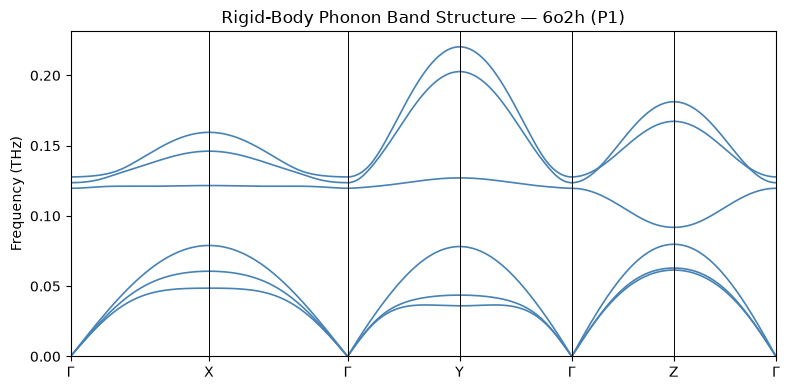

In [12]:
HSP = {'Γ':np.array([0.,0.,0.]),'X':np.array([.5,0.,0.]),
       'Y':np.array([0.,.5,0.]),'Z':np.array([0.,0.,.5])}
path_labels = ['Γ','X','Γ','Y','Γ','Z','Γ']
N_seg = 60

q_frac, tick_idx = [], [0]
for seg in range(len(path_labels)-1):
    p0, p1 = HSP[path_labels[seg]], HSP[path_labels[seg+1]]
    last = (seg == len(path_labels)-2)
    for t in np.linspace(0, 1, N_seg, endpoint=last):
        q_frac.append(p0*(1-t)+p1*t)
    if not last: tick_idx.append(len(q_frac))
tick_idx.append(len(q_frac)-1)

q_frac  = np.array(q_frac)
q_cart  = (B_recip @ q_frac.T).T
freqs_bs = []
for q in q_cart:
    D  = dynamical_matrix(q, unique, K_lab)
    ev = np.linalg.eigvalsh((Msq_inv @ D @ Msq_inv.T).real)
    freqs_bs.append(np.sqrt(np.maximum(ev,0)) * freq_unit)
freqs_bs = np.array(freqs_bs)

x = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(q_cart,axis=0),axis=1))])
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(x, freqs_bs, color='steelblue', lw=1.2)
for ti in tick_idx: ax.axvline(x[ti], color='k', lw=0.7)
ax.set_xticks([x[ti] for ti in tick_idx]); ax.set_xticklabels(path_labels)
ax.set_ylabel('Frequency (THz)'); ax.set_xlim(x[0],x[-1]); ax.set_ylim(0)
ax.set_title('Rigid-Body Phonon Band Structure — 6o2h (P1)')
plt.tight_layout(); plt.savefig('band_structure.png', dpi=150); plt.show()


Computing I(h,k,0) on 177×193 exact q-points  (Δh=Δk=1/8=0.1250, NPLOT_HK=8)...
Positive range: 0.162 – 2.2e+05  (clipped to 97th pct = 2.98e+04)
  Dark spots at integer (h,k): acoustic modes zeroed at Bragg positions — expected physics.
  Bright halos around Bragg spots: acoustic I(q) ~ |q-G|⁻² divergence (Huang scattering).


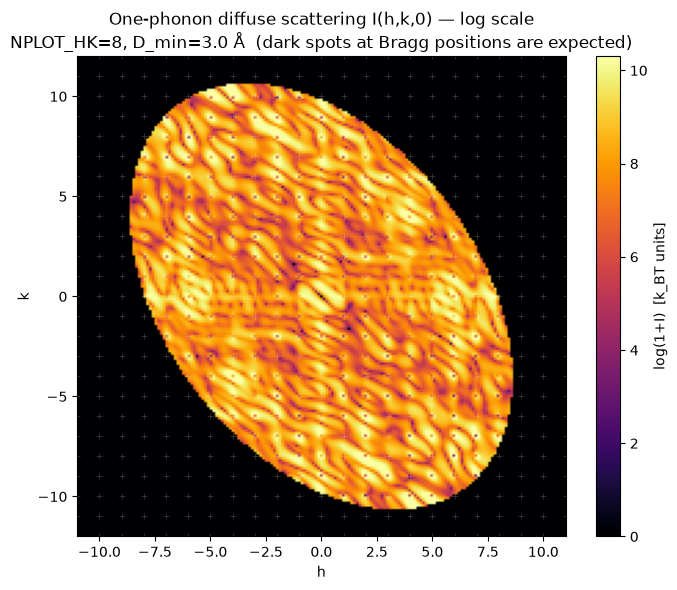

Saved diffuse_map_hk0.png


In [13]:
def safe_diffuse_intensity(G, D, min_eig_frac=1e-6):
    """
    Compute I = G† D⁻¹ G using eigendecomposition pseudo-inverse.
    Excludes eigenvalues < min_eig_frac * max_eigenvalue to avoid
    numerical blow-up from near-singular D(q) at soft-mode q-points.
    Returns 0.0 for near-singular matrices with no well-defined positive eigenvalues.
    """
    ev, evec = np.linalg.eigh(D.real)
    emax = ev.max()
    if emax < 1e-15: return 0.0
    threshold = min_eig_frac * emax
    pos = ev > threshold
    if not pos.any(): return 0.0
    ev_inv = np.where(pos, 1.0 / np.where(pos, ev, 1.0), 0.0)
    D_inv_G = evec @ (ev_inv * (evec.T @ G.real))
    return float(np.real(G.conj() @ D_inv_G))

def compute_diffuse_map(L_layer=0):
    """
    Compute I(h, k, L_layer) on a fine grid of EXACT q-points.

    h and k are sampled at multiples of 1/P = 1/NPLOT_HK, so each grid
    point corresponds to exactly one fine-grid sample of F_fine — no
    interpolation is performed at any step.  This is directly comparable
    with a sub-integer-resolution diffuse scattering dataset.

    To increase resolution: raise NPLOT_HK in the config cell (4→8 gives
    0.125 Miller-index spacing; memory scales as P³ for the fine FFT grid).
    """
    h_max = int(np.ceil(cell.a/D_MIN_DIFFUSE))+1
    k_max = int(np.ceil(cell.b/D_MIN_DIFFUSE))+1
    q_cut = 2*np.pi/D_MIN_DIFFUSE
    # Exact fine-grid points: multiples of 1/P — G_at_hkl lookup is integer-exact here
    h_pts = np.arange(-h_max * P, h_max * P + 1) / P
    k_pts = np.arange(-k_max * P, k_max * P + 1) / P
    NH, NK = len(h_pts), len(k_pts)
    print(f"Computing I(h,k,{L_layer}) on {NH}×{NK} exact q-points  "
          f"(Δh=Δk=1/{P}={1/P:.4f}, NPLOT_HK={P})...")
    I_map = np.zeros((NH, NK))
    for ih, h in enumerate(h_pts):
        for ik, k in enumerate(k_pts):
            q = h*B_recip[:,0] + k*B_recip[:,1] + L_layer*B_recip[:,2]
            qn = np.linalg.norm(q)
            if qn < 1e-3 or qn > q_cut:
                continue
            G = G_at_hkl(h, k, L_layer)
            D = dynamical_matrix(q, unique, K_lab)
            I_map[ih, ik] = safe_diffuse_intensity(G, D)
    return h_pts, k_pts, I_map, h_max, k_max

def plot_diffuse(h_pts, k_pts, I_map, h_max, k_max, L_layer, fname):
    """
    Plot the diffuse map.  DARK SPOTS at integer (h,k) positions are expected physics:

    D(q) is periodic with the reciprocal lattice, so D(G) = D(0) for every reciprocal
    lattice vector G.  D(0) has 3 exactly-zero acoustic eigenvalues; the pseudo-inverse
    zeros these at EVERY Bragg position, giving I(G) = optical-modes-only contribution.
    Just off a Bragg spot (q = G + δq, |δq| small), the acoustic eigenvalues go as
    c_s² |δq|² and D⁻¹ → 1/(c_s² |δq|²), producing the expected I(q) ~ |q-G|⁻² Huang
    scattering halos (bright rings around each dark Bragg spot).

    The ellipse boundary arises from the circular q-space cutoff |q| < 2π/D_MIN_DIFFUSE
    projected onto the (h,k) plane: h_max = ceil(a/D_min)+1, k_max = ceil(b/D_min)+1.
    To show fewer Bragg peaks with finer inter-Bragg resolution at fixed memory, increase
    D_MIN_DIFFUSE (larger → fewer peaks) and NPLOT_HK (larger P → finer sub-Bragg grid).
    """
    pos_vals = I_map[I_map > 0]
    if len(pos_vals) == 0:
        print("Warning: all I(q) = 0"); return

    # Clip to 97th percentile to avoid the very-bright halo pixels washing out
    # the weaker diffuse features far from Bragg spots.
    vmax = np.percentile(pos_vals, 97)
    I_plot = np.clip(I_map, 0, vmax)
    print(f"Positive range: {pos_vals.min():.3g} – {pos_vals.max():.3g}  "
          f"(clipped to 97th pct = {vmax:.3g})")
    print("  Dark spots at integer (h,k): acoustic modes zeroed at Bragg positions — expected physics.")
    print("  Bright halos around Bragg spots: acoustic I(q) ~ |q-G|⁻² divergence (Huang scattering).")

    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(np.log1p(I_plot).T, origin='lower', cmap='inferno',
                   extent=[-h_max, h_max, -k_max, k_max], aspect='auto')
    plt.colorbar(im, ax=ax, label='log(1+I)  [k_BT units]')
    ax.set_xlabel('h'); ax.set_ylabel('k')
    ax.set_title(f'One-phonon diffuse scattering I(h,k,{L_layer}) — log scale\n'
                 f'NPLOT_HK={P}, D_min={D_MIN_DIFFUSE} Å  '
                 f'(dark spots at Bragg positions are expected)')
    # Mark integer Bragg positions with faint crosses to identify them
    for hi in range(-h_max, h_max+1):
        for ki in range(-k_max, k_max+1):
            if hi == 0 and ki == 0: continue
            ax.plot(hi, ki, '+', color='white', alpha=0.25, markersize=4, markeredgewidth=0.5)
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()
    print(f"Saved {fname}")

# l=0 layer
h_pts0, k_pts0, I_map0, h_max0, k_max0 = compute_diffuse_map(L_layer=0)
plot_diffuse(h_pts0, k_pts0, I_map0, h_max0, k_max0, 0, 'diffuse_map_hk0.png')


Computing I(h,k,0.5) on 177×193 exact q-points  (Δh=Δk=1/8=0.1250, NPLOT_HK=8)...
Positive range: 1.57 – 4.8e+04  (clipped to 97th pct = 1.26e+04)
  Dark spots at integer (h,k): acoustic modes zeroed at Bragg positions — expected physics.
  Bright halos around Bragg spots: acoustic I(q) ~ |q-G|⁻² divergence (Huang scattering).


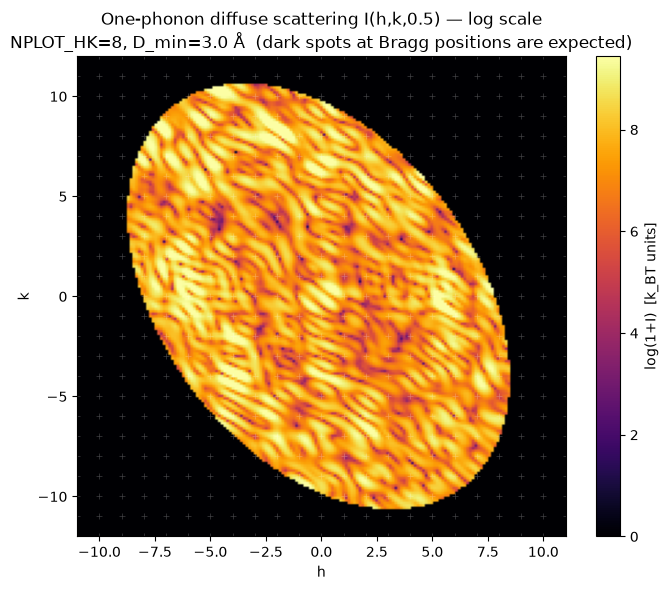

Saved diffuse_map_hk05.png


In [14]:
# l=0.5 layer — zone-boundary in c direction; often shows different TDS features
h_pts5, k_pts5, I_map5, h_max5, k_max5 = compute_diffuse_map(L_layer=0.5)
plot_diffuse(h_pts5, k_pts5, I_map5, h_max5, k_max5, 0.5, 'diffuse_map_hk05.png')


## Phonon Mode Visualization — GIF Animations

Each phonon mode at a chosen **q**-point is visualized as a looping GIF showing
the rigid-body motion of the molecule (Cα trace + all-atom backbone).

**What the printed quantities mean:**

- **Frequency (THz):** vibrational frequency. At a zone-boundary point like
  $\mathbf{q}=[0.5,0,0]$, modes with $\omega=0$ would indicate a pure acoustic
  branch instability — legitimately zero modes are the 3 acoustic modes
  *only at $\Gamma$*; at zone-boundary all 6 modes should be nonzero.

- **$|\Omega|$:** norm of the *rotational* component of the mass-weighted eigenvector.
  Units: rad·amu$^{-1/2}$·Å$^{-1}$ (the M-weighted eigenvector normalisation gives
  $\Omega^T J \Omega + v^T m v = 1$ for each mode).

- **$|v|$:** norm of the *translational* component of the mass-weighted eigenvector.
  It quantifies how much centre-of-mass translation contributes to the mode.
  A large $|v|$ means the molecule slides (acoustic-like at zone-boundary);
  a large $|\Omega|$ means it rocks/spins (optic-like librational mode).
  Together $|\Omega|^2 / (|\Omega|^2 + |v|^2)$ gives the rotational fraction.

**Animation scale:** AMPLITUDE Å = maximum per-atom displacement (scaled so the
largest displaced atom moves exactly AMPLITUDE Å, not the CM).

**Supercell wave:** The second GIF shows the q=[0.5,0,0] phonon as a $3\times3\times1$
supercell, revealing the wavelength character: cells alternate in phase along $\mathbf{a}_1$,
each completing exactly one full period over the 2-cell repeat length $2|\mathbf{a}_1|$.


In [15]:
# Install imageio and scikit-image if absent
import subprocess, sys, io
for pkg in ['imageio', 'scikit-image']:
    try:
        __import__(pkg.replace('-','_'))
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', pkg,
                        '--break-system-packages', '-q'], check=True)

import imageio
import imageio.v2 as iio2
from scipy.spatial.transform import Rotation as Rot
from skimage.measure import marching_cubes
from IPython.display import Image as IPImage, display
print(f"imageio {imageio.__version__}  ready.")


imageio 2.37.4  ready.


In [16]:
Q_VIZ     = np.array([0.5, 0.25, 0.0])  # fractional — zone-boundary but off-axis to avoid accidental zeros
AMPLITUDE = 3.0    # Å — maximum per-atom displacement
N_FRAMES  = 30     # frames per GIF cycle
GIF_FPS   = 12     # frames per second (looping)

q_viz  = B_recip @ Q_VIZ
D_viz  = dynamical_matrix(q_viz, unique, K_lab)
Dw_viz = (Msq_inv @ D_viz @ Msq_inv.T).real

# Use eigh for real symmetric matrix; check for any negative eigenvalues
ev_v, evec_v = np.linalg.eigh(Dw_viz)
print(f"Raw eigenvalues at q={Q_VIZ}: {ev_v.round(6)}")
print(f"  (negative → near-singular D; will clip to 0 → 0 Hz mode)")
ev_v         = np.maximum(ev_v, 0)
freqs_viz    = np.sqrt(ev_v) * freq_unit
evecs_lab    = Msq_inv.T @ evec_v   # (6,6) columns = lab-frame eigenvectors

# Print with high precision so near-zero frequencies are distinguishable
# Mode character: use KINETIC ENERGY fractions, not raw vector norms.
# M-weighted eigenvectors satisfy e^T M e = 1, i.e. Ω^T J Ω + v^T (m I) v = 1.
# So rot_KE_frac = Ω^T J Ω is already the rotational kinetic energy fraction.
print(f"\nModes at q={Q_VIZ}:")
hdr = f"{'Mode':>5} {'Freq (THz)':>14} {'|Ω|':>9} {'|v|':>9}  {'rot KE %':>9}  character"
print(hdr)
print('-'*len(hdr))
for s in range(6):
    Om = evecs_lab[:3, s].real
    v  = evecs_lab[3:, s].real
    nOm = np.linalg.norm(Om)
    nv  = np.linalg.norm(v)
    rot_KE = float(Om @ J @ Om)           # = Ω^T J Ω (fraction of KE in rotation)
    trans_KE = float(m_total * nv**2)     # = v^T (m I) v
    tot_KE = rot_KE + trans_KE
    rot_pct = 100 * rot_KE / max(tot_KE, 1e-30)
    char = 'librational' if rot_pct > 60 else ('translational' if rot_pct < 40 else 'mixed')
    print(f"  {s:3d}  {freqs_viz[s]:14.6f}  {nOm:9.4f}  {nv:9.4f}  {rot_pct:9.1f}%  {char}")
print()
print("M-weighted norm: Ω^T J Ω + v^T m v = 1 per mode.")
print("|v|  = CM-translation amplitude of eigenvector (Å·amu^{-1/2}); pure trans → |v|=1/√m ≈",
      f"{1/np.sqrt(m_total):.4f}")
print("|Ω|  = rotation amplitude (rad·amu^{-1/2}·Å^{-1}); pure rot → |Ω|~1/√J_avg")
print("rot KE% = Ω^T J Ω × 100  (fraction of kinetic energy carried by rotation)")


Raw eigenvalues at q=[0.5  0.25 0.  ]: [0.0004 0.0007 0.0011 0.0027 0.0045 0.0052]
  (negative → near-singular D; will clip to 0 → 0 Hz mode)

Modes at q=[0.5  0.25 0.  ]:
 Mode     Freq (THz)       |Ω|       |v|   rot KE %  character
--------------------------------------------------------------
    0        0.050335     0.0003     0.0074       15.9%  translational
    1        0.066058     0.0002     0.0076       10.4%  translational
    2        0.081975     0.0001     0.0080        0.6%  translational
    3        0.130420     0.0007     0.0020       93.8%  librational
    4        0.169167     0.0006     0.0027       89.2%  librational
    5        0.181390     0.0008     0.0025       90.0%  librational

M-weighted norm: Ω^T J Ω + v^T m v = 1 per mode.
|v|  = CM-translation amplitude of eigenvector (Å·amu^{-1/2}); pure trans → |v|=1/√m ≈ 0.0081
|Ω|  = rotation amplitude (rad·amu^{-1/2}·Å^{-1}); pure rot → |Ω|~1/√J_avg
rot KE% = Ω^T J Ω × 100  (fraction of kinetic energy carried by

In [17]:
# ── Surface visualization infrastructure ──────────────────────────────────────
# We use a MOLECULAR ISOSURFACE from the model electron density (marching cubes)
# instead of a convex hull, so that surface packing in the crystal can be seen.
# The isovalue (0.5% of peak density) encloses the protein van-der-Waals envelope.
# All ~5 000–20 000 vertices transform rigidly per frame — no recomputation.

from mpl_toolkits.mplot3d import Axes3D   # noqa
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

base_pos = apos.copy()   # (N_atoms, 3)
pts_cm   = base_pos - r_cm_at   # atom positions relative to CM (for calibration)

# --- Build molecular isosurface from model electron density -------------------
# rho_model has shape (nu_m, nv_m, nw_m); grid i→fractional i/nu_m → Cartesian A_orth @ frac
_iso_level = rho_model.max() * 0.005   # 0.5% of peak: encloses protein envelope
mc_verts_grid, mc_faces, _normals, _vals = marching_cubes(rho_model, level=_iso_level)

# Convert grid indices → Cartesian Å
_frac = mc_verts_grid / np.array([nu_m, nv_m, nw_m])
mc_verts_cart = (A_orth @ _frac.T).T                # (N_vert, 3) Cartesian
mc_verts_cm   = mc_verts_cart - r_cm_at             # centred at atom CM

print(f"Molecular isosurface (level={_iso_level:.3f} e/Å³): "
      f"{len(mc_verts_cm)} vertices, {len(mc_faces)} triangles.")

def displaced_mc(mode_idx, scale):
    """
    Return (N_vert, 3) isosurface vertices after rigid-body displacement of mode
    `mode_idx` with signed amplitude `scale` Å (max per-atom displacement = |scale|).
    """
    Om_raw = evecs_lab[:3, mode_idx].real.copy()
    v_raw  = evecs_lab[3:, mode_idx].real.copy()
    norm_vec = np.sqrt(Om_raw @ Om_raw + v_raw @ v_raw)
    if norm_vec < 1e-10:
        return mc_verts_cm + r_cm_at
    Om_u = Om_raw / norm_vec;  v_u = v_raw / norm_vec
    delta_unit = v_u[None, :] + np.cross(Om_u[None, :], pts_cm)  # (N_atoms,3)
    max_d = np.linalg.norm(delta_unit, axis=1).max()
    if max_d < 1e-12:
        return mc_verts_cm + r_cm_at
    fac = scale / max_d
    Om_s = fac * Om_u;  v_s = fac * v_u
    if abs(fac) * np.linalg.norm(Om_u) > 1e-10:
        new_verts = Rot.from_rotvec(Om_s).apply(mc_verts_cm) + r_cm_at + v_s
    else:
        new_verts = mc_verts_cm + r_cm_at + v_s
    return new_verts

def fig_to_image(fig, dpi=72):
    """Capture a matplotlib figure as an RGB numpy array via BytesIO.
    Works in all Jupyter backends — avoids canvas.tostring_rgb() fragility."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    buf.seek(0)
    img = iio2.imread(buf)
    return img[:, :, :3]   # drop alpha channel

# Equilibrium bounding box in lab frame (for axis limits)
eq_bbox_min = mc_verts_cart.min(axis=0)
eq_bbox_max = mc_verts_cart.max(axis=0)
print("Surface infrastructure ready.")


Molecular isosurface (level=0.085 e/Å³): 92925 vertices, 181529 triangles.
Surface infrastructure ready.


Generating surface GIFs at q=[0.5  0.25 0.  ]  (amplitude=3.0 Å max per-atom)...
Each mode: molecular isosurface, fixed color+opacity, looping GIF.

Mode 0: 0.050335 THz  ... saved → mode_0_q0.50_0.25_0.00.gif


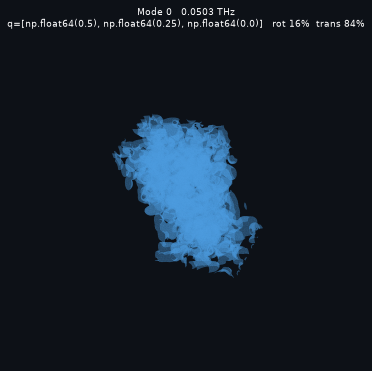

Mode 1: 0.066058 THz  ... saved → mode_1_q0.50_0.25_0.00.gif


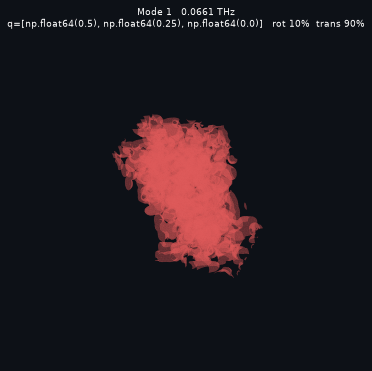

Mode 2: 0.081975 THz  ... 

In [ ]:
MODE_COLORS = ['#4e9de0', '#e05c5c', '#4fba74', '#e0b14e', '#a56be0', '#e07e4e']
SURF_ALPHA  = 0.50   # fixed opacity for every frame (translucent but visible)

# Fixed view angles — same for every frame so the GIF only shows motion, not rotation
ELEV, AZIM = 20, -60

def make_mode_gif(mode_idx, amplitude=AMPLITUDE, n_frames=N_FRAMES,
                  fps=GIF_FPS, fname=None, figsize=(6, 5)):
    """
    Render one phonon mode as a looping GIF using the molecular isosurface.
    Amplitude is calibrated so the heaviest-displaced atom moves exactly AMPLITUDE Å.
    Fixed color and fixed opacity so only the shape motion is visible.
    """
    if fname is None:
        qstr = '_'.join(f'{x:.2f}' for x in Q_VIZ)
        fname = f'mode_{mode_idx}_q{qstr}.gif'
    color = MODE_COLORS[mode_idx % len(MODE_COLORS)]

    scales = amplitude * np.sin(2*np.pi*np.arange(n_frames)/n_frames)

    # Axis limits from equilibrium molecular surface + padding
    pad = amplitude * 2.5
    xlim = (eq_bbox_min[0]-pad, eq_bbox_max[0]+pad)
    ylim = (eq_bbox_min[1]-pad, eq_bbox_max[1]+pad)
    zlim = (eq_bbox_min[2]-pad, eq_bbox_max[2]+pad)

    Om_r = evecs_lab[:3, mode_idx].real
    rot_KE    = float(Om_r @ J @ Om_r)
    trans_KE  = m_total * float(np.linalg.norm(evecs_lab[3:, mode_idx].real)**2)
    rot_pct   = 100*rot_KE/(rot_KE+trans_KE+1e-30)

    images = []
    for sc in scales:
        fig = plt.figure(figsize=figsize, facecolor='#0d1117')
        ax  = fig.add_subplot(111, projection='3d', facecolor='#0d1117')
        try:
            verts = displaced_mc(mode_idx, sc)   # (N_vert, 3) isosurface
            # Build triangle list (pre-indexed per face)
            tris = verts[mc_faces]               # (N_tri, 3, 3)
            poly = Poly3DCollection(tris, alpha=SURF_ALPHA, linewidths=0,
                                    facecolor=color, edgecolor='none')
            ax.add_collection3d(poly)

            ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
            ax.set_axis_off()
            ax.view_init(elev=ELEV, azim=AZIM)
            ax.set_title(
                f'Mode {mode_idx}   {freqs_viz[mode_idx]:.4f} THz\n'
                f'q={list(Q_VIZ)}   rot {rot_pct:.0f}%  trans {100-rot_pct:.0f}%',
                color='white', fontsize=8.5, pad=3)
            plt.tight_layout(pad=0.2)
            img = fig_to_image(fig)
            images.append(img)
        finally:
            plt.close(fig)

    imageio.mimsave(fname, images, fps=fps, loop=0)
    return fname

# ── Generate GIFs for all 6 modes ──────────────────────────────────────────────
print(f"Generating surface GIFs at q={Q_VIZ}  (amplitude={AMPLITUDE} Å max per-atom)...")
print("Each mode: molecular isosurface, fixed color+opacity, looping GIF.\n")
for s in range(6):
    print(f"Mode {s}: {freqs_viz[s]:.6f} THz", end="  ... ")
    try:
        path = make_mode_gif(s)
        print(f"saved → {path}")
        display(IPImage(filename=path))
    except Exception as e:
        print(f"FAILED: {e}")
print("\nDone.")


In [ ]:
# ── Supercell wave GIF — 3×3×3 unit cells ─────────────────────────────────────
# Each cell (i,j,k) is a rigid copy of the molecule displaced by
#   amplitude · cos(2π q_frac·[i,j,k] + 2π f/N)
# Fixed translucent surface (no phase-based recolouring) so only the shape
# deformation and wave propagation are visible, not a distracting colour change.

SUPER_N1   = 3      # supercell repeat along a1
SUPER_N2   = 3      # supercell repeat along a2
SUPER_N3   = 3      # supercell repeat along a3
MODE_SUPER = 0      # mode index to animate
SUPER_COLOR = '#4e9de0'   # single fixed surface colour
SUPER_ALPHA = 0.38         # fixed opacity — transparent enough to see through layers

def make_supercell_gif(mode_idx=MODE_SUPER, amplitude=AMPLITUDE,
                       n_frames=N_FRAMES, fps=GIF_FPS,
                       n1=SUPER_N1, n2=SUPER_N2, n3=SUPER_N3,
                       fname=None, figsize=(10, 9)):
    """
    Supercell phonon wave animation using molecular isosurfaces.
    Each of the n1×n2×n3 cells is rendered at FIXED colour and opacity;
    only the rigid-body displacements change per frame, revealing the
    wave character without distracting colour flicker.
    """
    if fname is None:
        qstr = '_'.join(f'{x:.2f}' for x in Q_VIZ)
        fname = f'supercell_mode{mode_idx}_q{qstr}.gif'

    cells_ijk = [(i,j,k) for i in range(n1) for j in range(n2) for k in range(n3)]
    phase0 = np.array([2*np.pi*(Q_VIZ[0]*i + Q_VIZ[1]*j + Q_VIZ[2]*k)
                       for i,j,k in cells_ijk])               # (n_cells,)
    T_cell = np.array([i*a1 + j*a2 + k*a3 for i,j,k in cells_ijk])  # (n_cells, 3)

    # Axis limits from equilibrium supercell isosurface + padding
    all_eq = np.vstack([mc_verts_cart + T for T in T_cell])
    pad = amplitude * 2.5
    xlim = (all_eq[:,0].min()-pad, all_eq[:,0].max()+pad)
    ylim = (all_eq[:,1].min()-pad, all_eq[:,1].max()+pad)
    zlim = (all_eq[:,2].min()-pad, all_eq[:,2].max()+pad)

    images = []
    for fi in range(n_frames):
        t = 2*np.pi*fi/n_frames
        fig = plt.figure(figsize=figsize, facecolor='#0d1117')
        ax  = fig.add_subplot(111, projection='3d', facecolor='#0d1117')
        try:
            for T, ph0 in zip(T_cell, phase0):
                phase_val = np.cos(ph0 + t)      # −1…+1
                sc = amplitude * phase_val
                verts = displaced_mc(mode_idx, sc) + T   # translate to supercell position

                tris_v = verts[mc_faces]          # (N_tri, 3, 3)
                poly = Poly3DCollection(tris_v, alpha=SUPER_ALPHA, linewidths=0,
                                        facecolor=SUPER_COLOR, edgecolor='none')
                ax.add_collection3d(poly)

            ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
            ax.set_axis_off()
            ax.view_init(elev=25, azim=-55)
            ax.set_title(
                f'Supercell phonon — Mode {mode_idx}  {freqs_viz[mode_idx]:.4f} THz\n'
                f'q={list(Q_VIZ)}   {n1}×{n2}×{n3} cells',
                color='white', fontsize=8.5, pad=3)
            plt.tight_layout(pad=0.2)
            img = fig_to_image(fig)
            images.append(img)
        finally:
            plt.close(fig)

    imageio.mimsave(fname, images, fps=fps, loop=0)
    return fname

print(f"Generating {SUPER_N1}×{SUPER_N2}×{SUPER_N3} supercell GIF for mode {MODE_SUPER}...")
try:
    sc_path = make_supercell_gif()
    print(f"Saved → {sc_path}")
    display(IPImage(filename=sc_path))
except Exception as e:
    print(f"Supercell GIF failed: {e}")
    import traceback; traceback.print_exc()


## Summary

| Output | File | Description |
|--------|------|-------------|
| Band structure | `band_structure.png` | Phonon dispersion Γ–X–Y–Z–Γ |
| Diffuse map l=0 | `diffuse_map_hk0.png` | TDS in hk0 plane |
| Diffuse map l=0.5 | `diffuse_map_hk05.png` | TDS at half-integer l |
| Mode GIFs | `mode_N_q*.gif` | All 6 modes at chosen q |
| Supercell wave | `supercell_mode*.gif` | 3×3×3 supercell phonon wave |

**Fitting K to data:** minimise $\sum_\mathbf{q}[I_{\rm obs}(\mathbf{q})-I_{\rm calc}(\mathbf{q})]^2$
over the $3\times 21=63$ parameters using $\nabla_K I = -G^\dagger D^{-1}(\partial D/\partial K)D^{-1}G$.

**Why D⁻¹ with pseudo-inverse?**
At some $\mathbf{q}$-points $D(\mathbf{q})$ can have very small eigenvalues
(soft modes, acoustic near-$\Gamma$, or numerical noise). A naive `np.linalg.solve`
blows up to $\sim 10^{52}$; the eigendecomposition pseudo-inverse discards
eigenvalues below a threshold ($10^{-6}$ of the maximum) and gives finite, physical $I(\mathbf{q})$.

**Frame choices for K:**
- *Midpoint frame* (`USE_MIDPOINT_FRAME=True`): symmetric in the two bodies;
  $K_{TT}^{zz}$ = stiffness pushing the two molecules apart,
  $K_{RR}$ = librational coupling at the interface.
- *Body-2/contact frame* (`False`): $B^T=(-\mathrm{Ad}_{g_{12}^{-1}}, I_6)$, natural for deriving $D(q)$.
- Both give identical physics; the lab-frame $D(q)$ is frame-independent.

**Supercell wave interpretation:**
At $\mathbf{q}=[0.5, 0.25, 0]$, the phonon has period $2a_1$ along $\hat{a}_1$
and $4a_2$ along $\hat{a}_2$. The 3×3×3 supercell makes the wavelength character
visible along all three axes simultaneously. Fixed colour and opacity mean only the
rigid-body displacement field (the wave) is animated, with no distracting colour flicker.

**What sets the diffuse map ellipse boundary:**
$h_{\rm max} = \lceil a/d_{\rm min}\rceil + 1$ and $k_{\rm max} = \lceil b/d_{\rm min}\rceil + 1$
where $d_{\rm min}$ = `D_MIN_DIFFUSE`. The circular Ewald cutoff $|\mathbf{q}| < 2\pi/d_{\rm min}$
maps to an ellipse in $(h, k)$ space because $|\mathbf{b}_1| \neq |\mathbf{b}_2|$.
To trade fewer Bragg peaks for finer inter-Bragg resolution at fixed memory: increase
`D_MIN_DIFFUSE` (reduces $h_{\rm max}$, $k_{\rm max}$) and increase `NPLOT_HK` proportionally.

**Dark spots at Bragg positions are expected physics:**
$D(\mathbf{G}) = D(\mathbf{0})$ for any reciprocal lattice vector $\mathbf{G}$ (periodicity of $D$).
The pseudo-inverse zeros the 3 acoustic modes at every $\mathbf{G}$, giving
$I(\mathbf{G})$ = optical-mode contribution only. Immediately around each Bragg spot
the acoustic contribution $I \sim |\mathbf{q}-\mathbf{G}|^{-2}$ (Huang scattering)
appears as a bright halo on the log-scale map.
